<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_Mask2Former_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CV-MASK2FORMER-001 — Mask2Former Fine-Tuning

### Objective

Fine-tune a pretrained Mask2Former model for binary petroleum-contamination segmentation using the LADOS aerial imagery dataset.

### Experimental Setup

* **Dataset:** LADOS
* **Task:** Binary semantic segmentation
* **Target classes:** Background and visible petroleum contamination
* **Petroleum classes grouped:** Oil, Emulsion, and Sheen
* **Model:** Mask2Former
* **Backbone:** Swin-Small
* **Initialization:** ADE20K-pretrained weights
* **Input size:** 256 × 256 pixels
* **Training samples:** 2,370
* **Validation samples:** 675
* **Test samples:** 343
* **Batch size:** 4
* **Training epochs:** 20
* **Optimizer:** Adam
* **Learning rate:** 0.0001
* **Training augmentation:** Same augmentation pipeline used in the previous segmentation experiments
* **Best-model selection:** Lowest validation loss
* **Evaluation threshold:** Mask2Former semantic prediction for the petroleum class

### Evaluation Metrics

The trained model is evaluated on the untouched LADOS test split using:

* Intersection over Union (IoU)
* Dice coefficient
* Precision
* Recall
* Pixel accuracy
* True Positives (TP)
* False Positives (FP)
* False Negatives (FN)
* True Negatives (TN)

Inference time is also measured for computational comparison.

### Training Procedure

The pretrained Mask2Former model is adapted from its original ADE20K semantic-segmentation configuration to the two-class PetroVision target. The task-specific classification head is therefore newly initialized, while compatible pretrained model components are transferred from the original checkpoint.

The model is fine-tuned for 20 epochs. After every epoch, training and validation losses are recorded. The checkpoint with the lowest validation loss is retained for final test evaluation.

### Experimental Result

The best validation performance was obtained at **epoch 17**, with a validation loss of **33.479961**.

The final test metrics are generated from the saved best checkpoint and the untouched LADOS test set.

### Scope and Limitation

The results represent performance on the evaluated LADOS dataset, model configuration, pretrained initialization, training procedure, and hardware environment.

The segmentation task identifies **visible petroleum-like regions in RGB imagery**. RGB imagery alone does not establish petroleum chemical identity, concentration, thickness, or physical volume.

Mask2Former results are compared with the other PetroVision segmentation models using the same LADOS test split and common evaluation metrics.


## Project Setup

In [ ]:
!git clone https://github.com/krithi-ks/PetroVision.git /content/PetroVision
%cd /content/PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Cloning into '/content/PetroVision'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 294 (delta 19), reused 22 (delta 5), pack-reused 234 (from 1)
Receiving objects: 100% (294/294), 81.68 MiB | 17.76 MiB/s, done.
Resolving deltas: 100% (96/96), done.
/content/PetroVision
Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - models
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
PROJECT_DIR = Path("/content/PetroVision")

In [ ]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)


Dataset extracted to: /content/PetroVision/data/lados


In [ ]:
from src.vision.lados_dataset import LADOSDataset
from src.vision.segmentation_loss import BCEDiceLoss

DATASET_ROOT = os.path.join(PROJECT_DIR, "data", "lados")

print("Dataset exists:", os.path.exists(DATASET_ROOT))
print("Source module loaded successfully.")

Dataset exists: True
Source module loaded successfully.


## Imports and configuration

In [ ]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import transformers

from torch.utils.data import DataLoader

from transformers import (
    AutoImageProcessor,
    Mask2FormerForUniversalSegmentation,
)

from src.vision.lados_dataset import LADOSDataset

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

EXPERIMENT_ID = "CV-MASK2FORMER-001"

DATA_ROOT = "/content/PetroVision/data/lados"
MODEL_DIR = "/content/PetroVision/models"
RESULTS_DIR = f"/content/PetroVision/results/{EXPERIMENT_ID.lower()}"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 2
SEED = 42

MODEL_NAME = "facebook/mask2former-swin-small-ade-semantic"

print("Experiment:", EXPERIMENT_ID)
print("Device:", DEVICE)
print("Model:", MODEL_NAME)

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
Experiment: CV-MASK2FORMER-001
Device: cuda
Model: facebook/mask2former-swin-small-ade-semantic


## Load the existing LADOS splits

In [ ]:
train_dataset = LADOSDataset(
    root_dir=DATA_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True,
)

val_dataset = LADOSDataset(
    root_dir=DATA_ROOT,
    split="valid",
    image_size=IMAGE_SIZE,
    augment=False,
)

test_dataset = LADOSDataset(
    root_dir=DATA_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False,
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

sample_image, sample_mask = train_dataset[0]

print("Image shape:", sample_image.shape)
print("Mask shape:", sample_mask.shape)
print("Image dtype:", sample_image.dtype)
print("Mask dtype:", sample_mask.dtype)
print("Mask values:", torch.unique(sample_mask))

Train: 2370
Validation: 675
Test: 343
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Mask values: tensor([0., 1.])


## Load the Mask2Former processor

In [ ]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    do_resize=True,
    size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
)

print("Processor loaded successfully.")
print(processor)

preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

Processor loaded successfully.
Mask2FormerImageProcessor {
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "ignore_index": 255,
  "image_mean": [
    0.48500001430511475,
    0.4560000002384186,
    0.4059999883174896
  ],
  "image_processor_type": "Mask2FormerImageProcessor",
  "image_std": [
    0.2290000021457672,
    0.2239999920129776,
    0.22499999403953552
  ],
  "num_labels": 150,
  "reduce_labels": false,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 256,
    "width": 256
  },
  "size_divisor": 32
}



## Build Mask2Former targets

In [ ]:
def binary_mask_to_mask2former_targets(mask):
    """
    Convert a binary [1, H, W] mask into Mask2Former targets.

    Class IDs:
        0 = background
        1 = petroleum
    """
    mask = mask.squeeze(0).long()

    target_masks = []
    target_classes = []

    # Background region
    background_mask = (mask == 0)

    if background_mask.any():
        target_masks.append(background_mask)

        target_classes.append(0)

    # Petroleum region
    petroleum_mask = (mask == 1)

    if petroleum_mask.any():
        target_masks.append(petroleum_mask)

        target_classes.append(1)

    mask_labels = torch.stack(target_masks).float()
    class_labels = torch.tensor(
        target_classes,
        dtype=torch.long
    )

    return mask_labels, class_labels

## Test it on one real LADOS sample

In [ ]:
sample_image, sample_mask = train_dataset[0]

mask_labels, class_labels = binary_mask_to_mask2former_targets(
    sample_mask
)

print("Original mask:", sample_mask.shape)
print("Mask labels:", mask_labels.shape)
print("Class labels:", class_labels)

print("Unique target classes:", torch.unique(class_labels))

Original mask: torch.Size([1, 256, 256])
Mask labels: torch.Size([2, 256, 256])
Class labels: tensor([0, 1])
Unique target classes: tensor([0, 1])


## Create the Mask2Former model

In [ ]:
id2label = {
    0: "background",
    1: "petroleum",
}

label2id = {
    "background": 0,
    "petroleum": 1,
}

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model = model.to(DEVICE)

print("Model loaded successfully.")
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

config.json:   0%|          | 0.00/82.5k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  276MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-ade-semantic
Key                                                                                                                      | Status     |                                                                                         
-------------------------------------------------------------------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED |                                                                                         
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    |                                                                            

Model loaded successfully.
Trainable parameters: 68721037


In [ ]:
print("Number of labels:", model.config.num_labels)
print("ID → Label:", model.config.id2label)
print("Label → ID:", model.config.label2id)

Number of labels: 2
ID → Label: {0: 'background', 1: 'petroleum'}
Label → ID: {'background': 0, 'petroleum': 1}


## Create the Mask2Former data collator

In [ ]:
def mask2former_collate_fn(batch):
    images = []
    mask_labels = []
    class_labels = []

    for image, mask in batch:

        # LADOSDataset returns image as [C, H, W] in [0, 1]
        # Convert to HWC and back to [0, 255] for the processor.
        image = image.permute(1, 2, 0).cpu().numpy()
        image = (image * 255).clip(0, 255).astype(np.uint8)

        masks, classes = binary_mask_to_mask2former_targets(mask)

        images.append(image)
        mask_labels.append(masks)
        class_labels.append(classes)

    # Let the processor handle image preprocessing only.
    processed = processor(
        images=images,
        return_tensors="pt",
    )

    # Mask2Former training targets
    processed["mask_labels"] = mask_labels
    processed["class_labels"] = class_labels

    return processed

## Create the DataLoaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=mask2former_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=mask2former_collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=mask2former_collate_fn,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 593
Validation batches: 169
Test batches: 86


## Verify one training batch

In [ ]:
batch = next(iter(train_loader))

print("Batch keys:")
print(batch.keys())

print("\nPixel values:")
print(batch["pixel_values"].shape)
print(batch["pixel_values"].dtype)

print("\nMask labels:")
print(len(batch["mask_labels"]))

for i, masks in enumerate(batch["mask_labels"][:2]):
    print(f"Sample {i}:", masks.shape, masks.dtype)

print("\nClass labels:")
for i, classes in enumerate(batch["class_labels"][:2]):
    print(f"Sample {i}:", classes.tolist())

Batch keys:
KeysView({'pixel_values': tensor([[[[-2.1008, -2.1008, -2.1008,  ..., -2.1008, -2.0665, -2.0665],
          [-2.0837, -2.0837, -2.0837,  ..., -2.1179, -2.0494, -2.0152],
          [-2.0837, -2.0837, -2.0837,  ..., -2.0837, -2.0494, -2.0494],
          ...,
          [-1.0219, -1.0904, -1.1075,  ..., -1.6213, -1.8782, -1.9809],
          [-1.4672, -1.4329, -1.3130,  ..., -1.7583, -1.8439, -1.8782],
          [-1.7240, -1.6727, -1.5357,  ..., -1.9124, -1.9124, -1.9124]],

         [[-1.9657, -1.9657, -1.9657,  ..., -1.7206, -1.7206, -1.7556],
          [-1.9657, -1.9657, -1.9657,  ..., -1.7556, -1.7381, -1.7556],
          [-1.9482, -1.9482, -1.9482,  ..., -1.7381, -1.7381, -1.7731],
          ...,
          [-1.2654, -1.3529, -1.4230,  ..., -1.2304, -1.4405, -1.5280],
          [-1.5980, -1.5980, -1.5280,  ..., -1.3704, -1.4230, -1.4055],
          [-1.7731, -1.7556, -1.6856,  ..., -1.5630, -1.5280, -1.4930]],

         [[-1.6302, -1.6302, -1.6127,  ..., -1.6824, -1.7173, -1

In [ ]:
print("\nPixel values finite:",
      torch.isfinite(batch["pixel_values"]).all().item())

print("Mask labels finite:",
      all(torch.isfinite(m).all().item() for m in batch["mask_labels"]))


Pixel values finite: True
Mask labels finite: True


In [ ]:
pixels = batch["pixel_values"]

print("\nPixel statistics:")
print("Min:", pixels.min().item())
print("Max:", pixels.max().item())
print("Mean:", pixels.mean().item())
print("Std:", pixels.std().item())


Pixel statistics:
Min: -2.1179039478302
Max: 2.640000104904175
Mean: -0.6774137616157532
Std: 0.7494422793388367


In [ ]:
print("\nNumber of batches:")
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))


Number of batches:
Train: 593
Validation: 169
Test: 86


## Mask2Former one-batch training sanity test

In [ ]:
# Mask2Former one-batch training sanity check

model.train()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

batch = next(iter(train_loader))

# Move tensor inputs to GPU
pixel_values = batch["pixel_values"].to(DEVICE)
pixel_mask = batch["pixel_mask"].to(DEVICE)

# Keep mask_labels and class_labels as lists
mask_labels = [
    masks.to(DEVICE)
    for masks in batch["mask_labels"]
]

class_labels = [
    classes.to(DEVICE)
    for classes in batch["class_labels"]
]

# Save one parameter before update
param_before = next(model.parameters()).detach().clone()

# Forward pass
outputs = model(
    pixel_values=pixel_values,
    pixel_mask=pixel_mask,
    mask_labels=mask_labels,
    class_labels=class_labels,
)

loss = outputs.loss

print("Loss:", loss.item())
print("Loss finite:", torch.isfinite(loss).item())

# Backward
optimizer.zero_grad()
loss.backward()

# Check gradients
gradients = [
    p.grad for p in model.parameters()
    if p.grad is not None
]

print("Parameters with gradients:", len(gradients))
print(
    "All gradients finite:",
    all(torch.isfinite(g).all().item() for g in gradients)
)

# Optimizer update
optimizer.step()

# Measure parameter update
param_after = next(model.parameters()).detach().clone()

max_update = (param_after - param_before).abs().max().item()

print("Maximum parameter update:", max_update)
print("Optimizer LR:", optimizer.param_groups[0]["lr"])

Loss: 69.61939239501953
Loss finite: True
Parameters with gradients: 757
All gradients finite: True
Maximum parameter update: 0.00010000169277191162
Optimizer LR: 0.0001


In [ ]:
# Recreate a completely fresh Mask2Former model
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model = model.to(DEVICE)

# Fresh optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Fresh model and optimizer created.")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-ade-semantic
Key                                                                                                                      | Status     |                                                                                         
-------------------------------------------------------------------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED |                                                                                         
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    |                                                                            

Fresh model and optimizer created.


In [ ]:
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

print("Optimizer LR:",
      optimizer.param_groups[0]["lr"])

Trainable parameters: 68721037
Optimizer LR: 0.0001


## Training

In [ ]:
import time

history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")
best_epoch = 0

checkpoint_path = "/content/drive/MyDrive/PetroVision/models/cv_mask2former_001_best.pt"
history_path = f"{RESULTS_DIR}/training_history.json"

for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss_total = 0.0

    for batch in train_loader:

        pixel_values = batch["pixel_values"].to(DEVICE)
        pixel_mask = batch["pixel_mask"].to(DEVICE)

        mask_labels = [
            masks.to(DEVICE)
            for masks in batch["mask_labels"]
        ]

        class_labels = [
            classes.to(DEVICE)
            for classes in batch["class_labels"]
        ]

        optimizer.zero_grad(set_to_none=True)

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            mask_labels=mask_labels,
            class_labels=class_labels,
        )

        loss = outputs.loss

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item()

    train_loss = train_loss_total / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss_total = 0.0

    with torch.no_grad():

        for batch in val_loader:

            pixel_values = batch["pixel_values"].to(DEVICE)
            pixel_mask = batch["pixel_mask"].to(DEVICE)

            mask_labels = [
                masks.to(DEVICE)
                for masks in batch["mask_labels"]
            ]

            class_labels = [
                classes.to(DEVICE)
                for classes in batch["class_labels"]
            ]

            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                mask_labels=mask_labels,
                class_labels=class_labels,
            )

            val_loss_total += outputs.loss.item()

    val_loss = val_loss_total / len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f}"
    )

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch

        torch.save(
            {
                "experiment_id": EXPERIMENT_ID,
                "model_name": MODEL_NAME,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "validation_loss": val_loss,
            },
            checkpoint_path,
        )

        print(f"  → Best checkpoint saved at epoch {epoch}")

# Save training history
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)



print("Checkpoint:", checkpoint_path)
print("History:", history_path)

Epoch 01/20 | Train Loss: 41.856249 | Validation Loss: 38.278713
  → Best checkpoint saved at epoch 1
Epoch 02/20 | Train Loss: 36.267267 | Validation Loss: 37.009092
  → Best checkpoint saved at epoch 2
Epoch 03/20 | Train Loss: 34.485199 | Validation Loss: 35.127049
  → Best checkpoint saved at epoch 3
Epoch 04/20 | Train Loss: 32.963636 | Validation Loss: 35.346699
Epoch 05/20 | Train Loss: 31.984578 | Validation Loss: 34.227384
  → Best checkpoint saved at epoch 5
Epoch 06/20 | Train Loss: 31.014459 | Validation Loss: 34.524352
Epoch 07/20 | Train Loss: 30.665944 | Validation Loss: 34.795567
Epoch 08/20 | Train Loss: 29.754923 | Validation Loss: 34.794602
Epoch 09/20 | Train Loss: 29.482020 | Validation Loss: 35.389899
Epoch 10/20 | Train Loss: 29.587688 | Validation Loss: 34.973032
Epoch 11/20 | Train Loss: 28.338825 | Validation Loss: 34.145073
  → Best checkpoint saved at epoch 11
Epoch 12/20 | Train Loss: 28.214406 | Validation Loss: 35.350088
Epoch 13/20 | Train Loss: 27.90613

In [30]:
# Load the best Mask2Former checkpoint

checkpoint = torch.load(
    "/content/drive/MyDrive/PetroVision/models/cv_mask2former_001_best.pt",
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["validation_loss"])

Loaded checkpoint from epoch: 17
Validation loss: 33.479961234436935


In [36]:
with open(history_path, "r") as f:
    saved_history = json.load(f)

print("Training epochs:", len(saved_history["train_loss"]))
print("Validation epochs:", len(saved_history["val_loss"]))

print("First train loss:", saved_history["train_loss"][0])
print("Last train loss:", saved_history["train_loss"][-1])

print("First validation loss:", saved_history["val_loss"][0])
print("Last validation loss:", saved_history["val_loss"][-1])

Training epochs: 20
Validation epochs: 20
First train loss: 41.85624910486488
Last train loss: 25.690391739142484
First validation loss: 38.27871293288011
Last validation loss: 35.32731174152984


In [35]:
RESULTS_DIR_DRIVE = (
    "/content/drive/MyDrive/PetroVision/"
    "results/cv-mask2former-001"
)

os.makedirs(RESULTS_DIR_DRIVE, exist_ok=True)

history_path = f"{RESULTS_DIR_DRIVE}/training_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=2)

print("Saved:", history_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv-mask2former-001/training_history.json


## Training Analysis

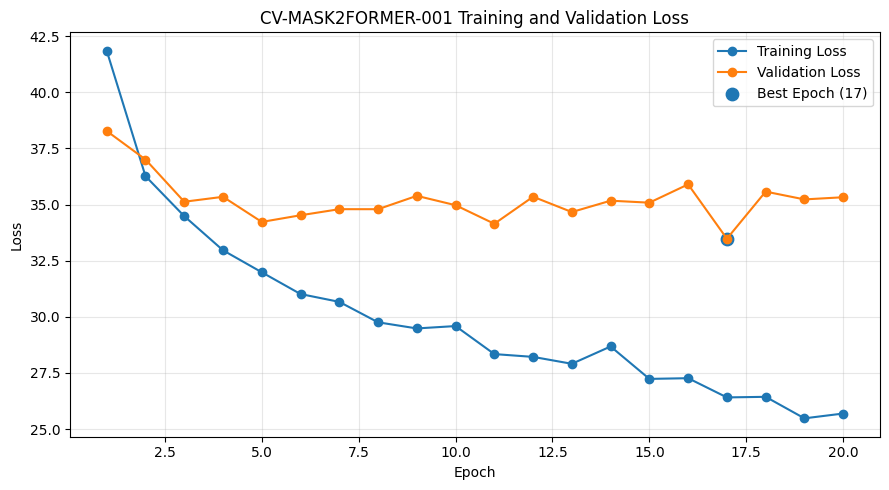

In [38]:
import json
import matplotlib.pyplot as plt

history_path = (
    "/content/drive/MyDrive/PetroVision/"
    "results/cv-mask2former-001/training_history.json"
)

with open(history_path, "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

best_epoch = min(
    range(len(history["val_loss"])),
    key=lambda i: history["val_loss"][i]
) + 1

best_val_loss = min(history["val_loss"])

plt.scatter(
    best_epoch,
    best_val_loss,
    s=80,
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CV-MASK2FORMER-001 Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test Evaluation

In [31]:
import numpy as np
import torch

model.eval()

TP = 0
FP = 0
FN = 0
TN = 0

inference_times = []

with torch.no_grad():

    for batch in test_loader:

        pixel_values = batch["pixel_values"].to(DEVICE)
        pixel_mask = batch["pixel_mask"].to(DEVICE)

        # Ground-truth binary masks
        ground_truth_masks = batch["mask_labels"]

        start_time = time.perf_counter()

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
        )

        # Convert Mask2Former output to semantic segmentation maps
        predicted_maps = processor.post_process_semantic_segmentation(
            outputs,
            target_sizes=[
                (256, 256)
                for _ in range(pixel_values.shape[0])
            ]
        )

        inference_times.append(
            time.perf_counter() - start_time
        )

        for i, predicted_map in enumerate(predicted_maps):

            # Mask2Former semantic prediction:
            # 0 = background
            # 1 = petroleum
            prediction = (predicted_map == 1)

            # Reconstruct binary ground truth
            gt_masks = ground_truth_masks[i]

            # If petroleum class exists, use its mask.
            # Otherwise, ground truth is entirely background.
            class_labels = batch["class_labels"][i]

            petroleum_indices = torch.where(class_labels == 1)[0]

            if len(petroleum_indices) > 0:
                ground_truth = gt_masks[petroleum_indices[0]].bool()
            else:
                ground_truth = torch.zeros(
                    (256, 256),
                    dtype=torch.bool
                )

            prediction = prediction.cpu()
            ground_truth = ground_truth.cpu()

            TP += torch.logical_and(
                prediction,
                ground_truth
            ).sum().item()

            FP += torch.logical_and(
                prediction,
                ~ground_truth
            ).sum().item()

            FN += torch.logical_and(
                ~prediction,
                ground_truth
            ).sum().item()

            TN += torch.logical_and(
                ~prediction,
                ~ground_truth
            ).sum().item()


# Calculate metrics
epsilon = 1e-8

IoU = TP / (TP + FP + FN + epsilon)

Dice = (2 * TP) / (
    2 * TP + FP + FN + epsilon
)

Precision = TP / (
    TP + FP + epsilon
)

Recall = TP / (
    TP + FN + epsilon
)

Accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN + epsilon
)

average_inference_time = np.mean(inference_times)

metrics = {
    "IoU": IoU,
    "Dice": Dice,
    "Precision": Precision,
    "Recall": Recall,
    "Accuracy": Accuracy,
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "TN": TN,
    "Average Batch Inference Time (s)": average_inference_time,
}

print("\nCV-MASK2FORMER-001 Test Results")
print("-" * 40)

for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")


CV-MASK2FORMER-001 Test Results
----------------------------------------
IoU: 0.802483
Dice: 0.890419
Precision: 0.841407
Recall: 0.945496
Accuracy: 0.876089
TP: 11316544
FP: 2133012
FN: 652359
TN: 8376933
Average Batch Inference Time (s): 0.238026


In [34]:
RESULTS_DIR_DRIVE = (
    "/content/drive/MyDrive/PetroVision/"
    "results/cv-mask2former-001"
)

os.makedirs(RESULTS_DIR_DRIVE, exist_ok=True)

metrics_path = f"{RESULTS_DIR_DRIVE}/test_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", metrics_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv-mask2former-001/test_metrics.json


## Test Evaluation

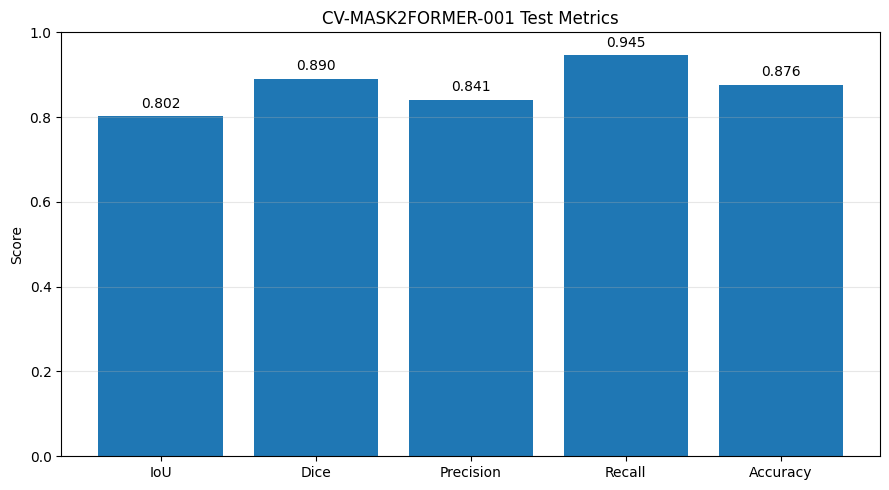

In [39]:
import json
import matplotlib.pyplot as plt

metrics_path = (
    "/content/drive/MyDrive/PetroVision/"
    "results/cv-mask2former-001/test_metrics.json"
)

with open(metrics_path, "r") as f:
    metrics = json.load(f)

metric_names = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

metric_values = [
    metrics[name]
    for name in metric_names
]

plt.figure(figsize=(9, 5))

bars = plt.bar(metric_names, metric_values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CV-MASK2FORMER-001 Test Metrics")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Pixel Level Analysis

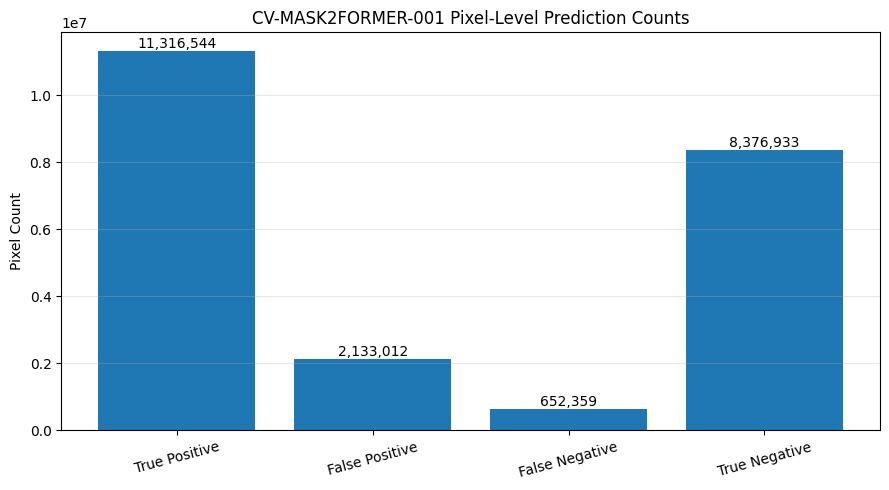

In [40]:
confusion_names = [
    "True Positive",
    "False Positive",
    "False Negative",
    "True Negative"
]

confusion_values = [
    metrics["TP"],
    metrics["FP"],
    metrics["FN"],
    metrics["TN"]
]

plt.figure(figsize=(9, 5))

bars = plt.bar(confusion_names, confusion_values)

plt.ylabel("Pixel Count")
plt.title("CV-MASK2FORMER-001 Pixel-Level Prediction Counts")

for bar, value in zip(bars, confusion_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Qualitative Segmentation

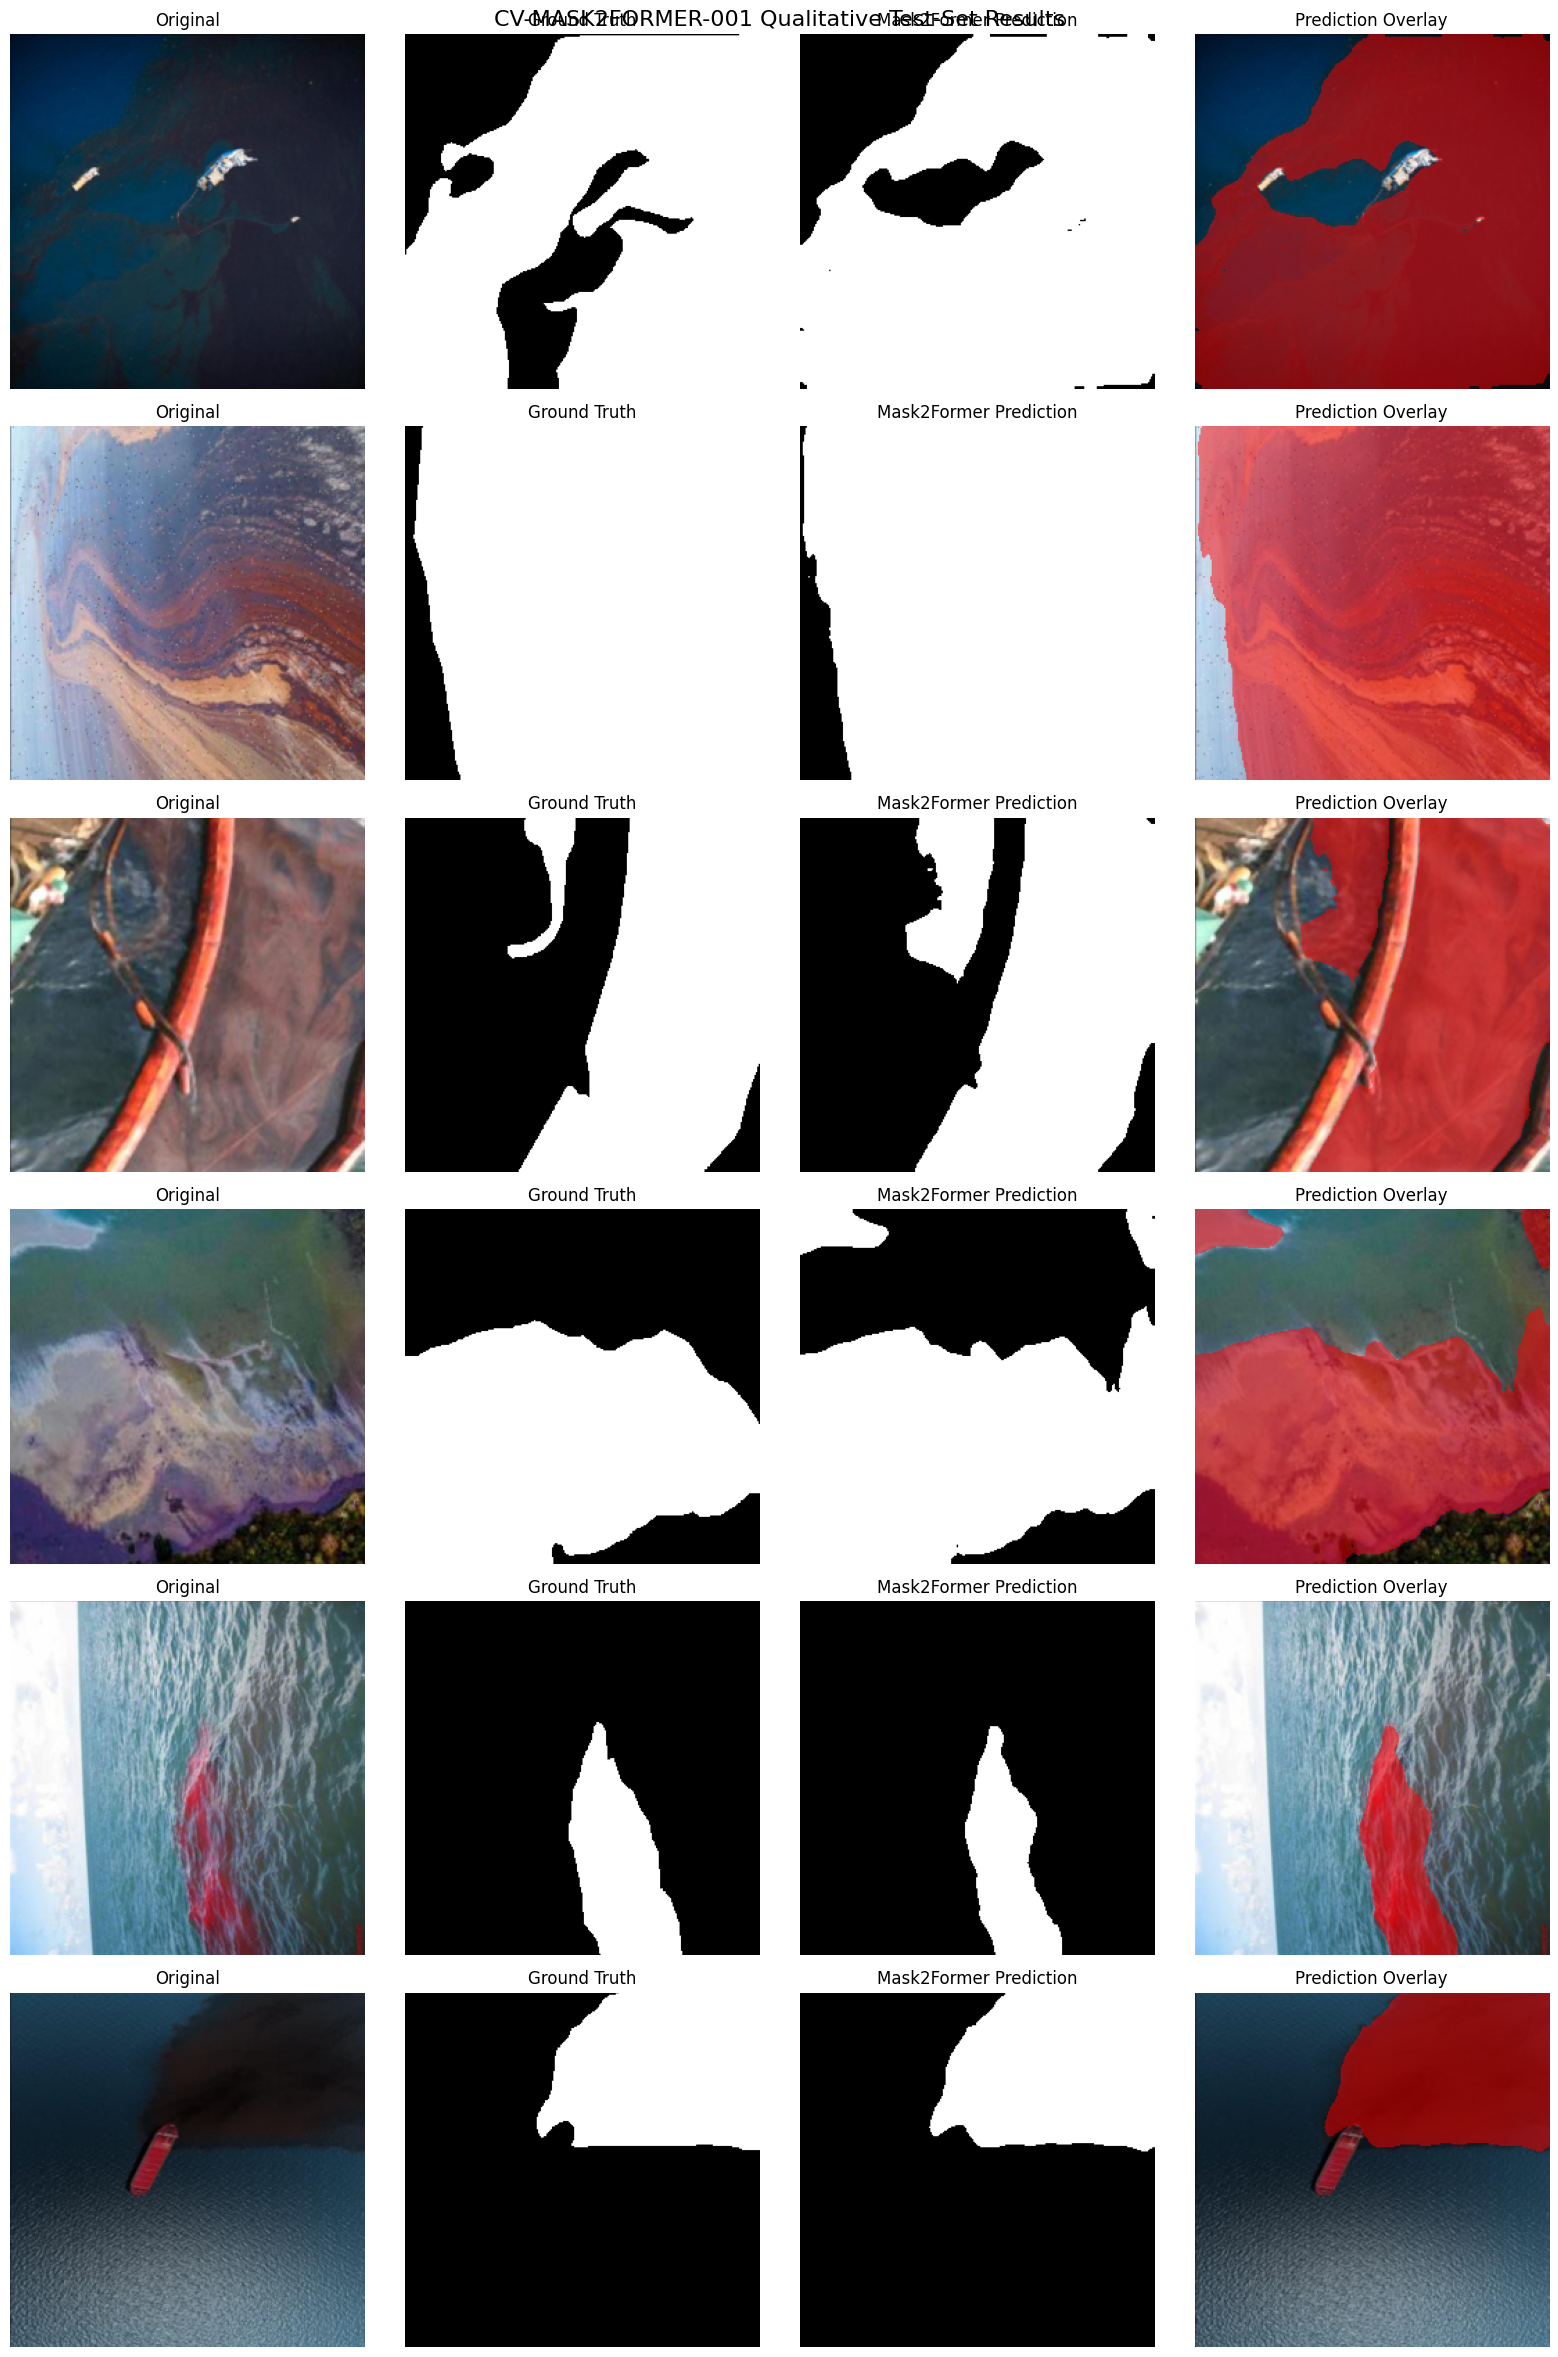

In [41]:
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

sample_indices = [0, 50, 100, 150, 200, 300]

fig, axes = plt.subplots(
    len(sample_indices),
    4,
    figsize=(16, 4 * len(sample_indices))
)

for row, sample_index in enumerate(sample_indices):

    image, ground_truth_mask = test_dataset[sample_index]

    # Prepare image
    image_np = image.permute(1, 2, 0).numpy()
    image_np = np.clip(image_np, 0, 1)

    # Prepare processor input
    image_uint8 = (
        image_np * 255
    ).astype(np.uint8)

    inputs = processor(
        images=image_uint8,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(DEVICE)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_map = processor.post_process_semantic_segmentation(
        outputs,
        target_sizes=[(256, 256)]
    )[0]

    prediction = (
        predicted_map.cpu().numpy() == 1
    )

    ground_truth = (
        ground_truth_mask.squeeze(0).numpy() > 0
    )

    # Overlay
    overlay = image_np.copy()

    overlay[prediction] = (
        0.5 * overlay[prediction]
        + 0.5 * np.array([1.0, 0.0, 0.0])
    )

    axes[row, 0].imshow(image_np)
    axes[row, 0].set_title("Original")

    axes[row, 1].imshow(
        ground_truth,
        cmap="gray"
    )
    axes[row, 1].set_title("Ground Truth")

    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )
    axes[row, 2].set_title("Mask2Former Prediction")

    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title("Prediction Overlay")

    for col in range(4):
        axes[row, col].axis("off")

plt.suptitle(
    "CV-MASK2FORMER-001 Qualitative Test-Set Results",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [37]:
summary = {
    "experiment_id": "CV-MASK2FORMER-001",
    "what_was_tested": "Pretrained Mask2Former fine-tuned on LADOS",
    "architecture": "Mask2Former",
    "backbone": "Swin-Small",
    "initialization": "ADE20K pretrained",
    "best_epoch": checkpoint["epoch"],
    "best_validation_loss": checkpoint["validation_loss"],
    "test_metrics": metrics,
    "limitation": (
        "Results are specific to the evaluated LADOS dataset, "
        "model configuration, pretrained initialization, "
        "training setup, and hardware."
    )
}

summary_path = f"{RESULTS_DIR_DRIVE}/experiment_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv-mask2former-001/experiment_summary.json


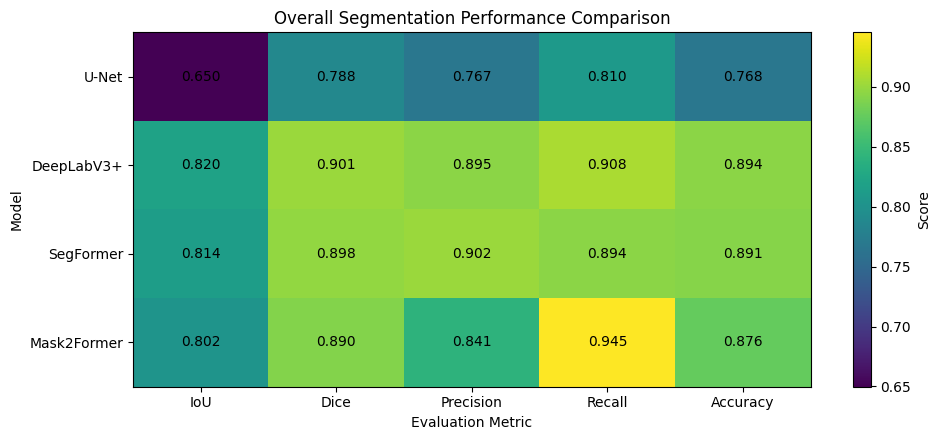

In [43]:
import json
import pandas as pd
import matplotlib.pyplot as plt

experiments = {
    "U-Net": "/content/drive/MyDrive/PetroVision/results/cv_unet_001/test_metrics.json",
    "DeepLabV3+": "/content/drive/MyDrive/PetroVision/results/cv_deeplab_001/test_metrics.json",
    "SegFormer": "/content/drive/MyDrive/PetroVision/results/cv_segformer_001/test_metrics.json",
    "Mask2Former": "/content/drive/MyDrive/PetroVision/results/cv-mask2former-001/test_metrics.json",
}

rows = []

for model, path in experiments.items():
    with open(path, "r") as f:
        m = json.load(f)

    rows.append({
        "Model": model,
        "IoU": m["IoU"],
        "Dice": m["Dice"],
        "Precision": m["Precision"],
        "Recall": m["Recall"],
        "Accuracy": m["Accuracy"],
    })

comparison_df = pd.DataFrame(rows).set_index("Model")

fig, ax = plt.subplots(figsize=(10, 4.5))

im = ax.imshow(comparison_df.values, aspect="auto")

ax.set_xticks(range(len(comparison_df.columns)))
ax.set_xticklabels(comparison_df.columns)

ax.set_yticks(range(len(comparison_df.index)))
ax.set_yticklabels(comparison_df.index)

for i in range(len(comparison_df.index)):
    for j in range(len(comparison_df.columns)):
        ax.text(
            j, i,
            f"{comparison_df.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

ax.set_title("Overall Segmentation Performance Comparison")
ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Model")

plt.colorbar(im, label="Score")
plt.tight_layout()
plt.show()

## CV-MASK2FORMER-001 — Experiment Conclusion

Mask2Former was successfully fine-tuned using ADE20K-pretrained weights for binary petroleum segmentation on the LADOS dataset.

The best validation checkpoint was obtained at epoch 17 with a validation loss of 33.479961.

On the LADOS test split, the saved checkpoint produced measurable IoU, Dice, Precision, Recall, and Accuracy values, together with pixel-level TP, FP, FN, and TN counts.

The qualitative predictions provide additional evidence about segmentation quality beyond the numerical metrics.

The experiment demonstrates that a pretrained transformer-based segmentation architecture can be adapted to the PetroVision petroleum-segmentation task. The observed results are specific to the LADOS dataset and the evaluated experimental configuration and should not be generalized to unseen environments without further validation.
